In [89]:
import torch
import torch.nn as nn
import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib import cm
from collections import OrderedDict

In [90]:
################################################################################
# PINN for the 2D Wave Equation (First-order System Form)
#
# PDE System:
#   du/dt = v
#   dv/dt = c^2 * (u_xx + u_yy)
# Domain:
#   t in [0, T], x in [0, Lx], y in [0, Ly]
# Initial Conditions:
#   u(0, x, y)  = f1(x, y) = sin(pi*x) * sin(pi*y)
#   v(0, x, y)  = f2(x, y) = 0  (since ut(0, x, y) = 0)
# Boundary Conditions:
#   u(t, 0, y) = u(t, Lx, y) = u(t, x, 0) = u(t, x, Ly) = 0
#   v(t, 0, y) = v(t, Lx, y) = v(t, x, 0) = v(t, x, Ly) = 0
#
################################################################################

# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [91]:
################################################################################
# Hyperparameters / Problem Setup
################################################################################
Lx = 1.0     # Spatial domain: x in [0, Lx]
Ly = 1.0     # Spatial domain: y in [0, Ly]
T = 1.0      # Temporal domain: t in [0, T]
c = 1.0      # Wave speed

n_collocation = 5000  # Number of collocation points inside domain
n_boundary    = 500   # Number of points for boundary conditions (each boundary)
n_initial     = 1000  # Number of points for initial conditions
hidden_layers = 6     # Number of hidden layers
neurons       = 50    # Neurons per hidden layer
learning_rate = 1e-3  # Learning rate for optimizer
num_epochs    = 10000 # Training epochs

In [92]:
################################################################################
# 2D MMPDE Sampling Class for 2D Wave Equation
################################################################################
# DNN class for MMPDE
class DNN(torch.nn.Module):
    def __init__(self, layers):
        super(DNN, self).__init__()

        # parameters
        self.depth = len(layers) - 1

        # set up layer order dict
        self.activation = torch.nn.Tanh

        layer_list = list()
        for i in range(self.depth - 1):
            layer_list.append(
                ('layer_%d' % i, torch.nn.Linear(layers[i], layers[i + 1]))
            )
            layer_list.append(('activation_%d' % i, self.activation()))

        layer_list.append(
            ('layer_%d' % (self.depth - 1), torch.nn.Linear(layers[-2], layers[-1]))
        )
        layerDict = OrderedDict(layer_list)

        # deploy layers
        self.layers = torch.nn.Sequential(layerDict)

    def forward(self, x):
        out = self.layers(x)
        return out

class sampling_MMPDE_2D():
    def __init__(self, X_f, u_fun, layers, lb, ub, nu, AdamIter, LBFGSIter):
        # 边界条件 [t_min, x_min, y_min], [t_max, x_max, y_max]
        self.lb = torch.tensor(lb).float().to(device)
        self.ub = torch.tensor(ub).float().to(device)

        # 数据 - 输入格式: [t, x, y]
        self.t_f = torch.tensor(X_f[:, 0:1], requires_grad=True).float().to(device)
        self.x_f = torch.tensor(X_f[:, 1:2], requires_grad=True).float().to(device)
        self.y_f = torch.tensor(X_f[:, 2:3], requires_grad=True).float().to(device)
        self.fun = u_fun

        self.layers = layers
        self.nu = nu

        # 深度神经网络 - 输入(t,x,y)，输出新的(x,y)坐标
        self.dnn = DNN(layers).to(device)

        # 优化器设置
        self.optimizer_Adam = torch.optim.Adam(self.dnn.parameters(),
                                              lr=1e-3,
                                              betas=(0.9, 0.999),
                                              eps=1e-8)
        
        self.AdamIter = AdamIter

        self.optimizer_LBFGS = torch.optim.LBFGS(
            self.dnn.parameters(),
            lr=0.5,
            max_iter=LBFGSIter,
        )

        self.optimizer = None
        self.loss = None
        self.iter = 0
        self.start_time = None

    def detach(self, data):
        return data.detach().cpu().numpy()

    def monitor(self, t, x, y):

        t.requires_grad_(True)
        x.requires_grad_(True) 
        y.requires_grad_(True)
        
        # 使用当前的t,x,y计算解
        inputs = torch.cat([t, x, y], dim=1)
        uv = self.fun(inputs)
        u = uv[:, [0]]  # 位移u
        v = uv[:, [1]]  # 速度v = u_t

        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True,
            allow_unused=True
        )[0]
        
        u_y = torch.autograd.grad(
            u, y,
            grad_outputs=torch.ones_like(u),
            retain_graph=True,
            create_graph=True,
            allow_unused=True
        )[0]

        # 计算v的时间导数 (v_t = u_tt)
        v_t = torch.autograd.grad(
            v, t,
            grad_outputs=torch.ones_like(v),
            retain_graph=True,
            create_graph=True,
            allow_unused=True
        )[0]

        # 处理可能为None的梯度
        if u_x is None:
            u_x = torch.zeros_like(u)
        if u_y is None:
            u_y = torch.zeros_like(u)
        if v_t is None:
            v_t = torch.zeros_like(v)

        # 监测函数：结合空间梯度和时间二阶导数
        w = (1 + (u_x)**2 + (u_y)**2 + (v_t)**2) ** (1/2)
        
        return w

    def net_sample(self, t, x, y):
        """
        生成新的采样点 - 对x和y坐标进行自适应调整
        """
        inputs = torch.cat([t, x, y], dim=1)
        xy_new = self.dnn(inputs)
        
        # 分离x和y的新坐标
        x_new = xy_new[:, [0]]
        y_new = xy_new[:, [1]]
        
        # 应用边界条件约束
        gx0 = x - self.lb[1]  # x - x_min
        gx1 = x - self.ub[1]  # x - x_max
        gy0 = y - self.lb[2]  # y - y_min  
        gy1 = y - self.ub[2]  # y - y_max
        
        # 确保新坐标在边界处为原坐标
        x_new = gx0 * gx1 * x_new + x
        y_new = gy0 * gy1 * y_new + y
        
        return x_new, y_new

    def net_f(self, t, x, y):
        """
        计算2D MMPDE方程的残差
        """
        x_new, y_new = self.net_sample(t, x, y)

        # 计算新坐标的时间导数
        x_new_t = torch.autograd.grad(
            x_new, t,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_t = torch.autograd.grad(
            y_new, t,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        # 计算新坐标的空间导数
        x_new_x = torch.autograd.grad(
            x_new, x,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        x_new_y = torch.autograd.grad(
            x_new, y,
            grad_outputs=torch.ones_like(x_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_x = torch.autograd.grad(
            y_new, x,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_y = torch.autograd.grad(
            y_new, y,
            grad_outputs=torch.ones_like(y_new),
            retain_graph=True,
            create_graph=True
        )[0]

        # 计算新坐标的二阶导数
        x_new_xx = torch.autograd.grad(
            x_new_x, x,
            grad_outputs=torch.ones_like(x_new_x),
            retain_graph=True,
            create_graph=True
        )[0]

        x_new_yy = torch.autograd.grad(
            x_new_y, y,
            grad_outputs=torch.ones_like(x_new_y),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_xx = torch.autograd.grad(
            y_new_x, x,
            grad_outputs=torch.ones_like(y_new_x),
            retain_graph=True,
            create_graph=True
        )[0]

        y_new_yy = torch.autograd.grad(
            y_new_y, y,
            grad_outputs=torch.ones_like(y_new_y),
            retain_graph=True,
            create_graph=True
        )[0]

        G = self.monitor(t, x, y)

        G_t = torch.autograd.grad(
            G, t,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_x = torch.autograd.grad(
            G, x,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        G_y = torch.autograd.grad(
            G, y,
            grad_outputs=torch.ones_like(G),
            retain_graph=True,
            create_graph=True
        )[0]

        # 2D MMPDE方程的残差
        # For x coordinate:
        E_x = G_x * x_new_x + G_y * x_new_y + G * (x_new_xx + x_new_yy)
        f_x = x_new_t * self.nu * (G**2) * (x_new_x**2 + x_new_y**2) + E_x

        # For y coordinate:
        E_y = G_x * y_new_x + G_y * y_new_y + G * (y_new_xx + y_new_yy)
        f_y = y_new_t * self.nu * (G**2) * (y_new_x**2 + y_new_y**2) + E_y

        return f_x, f_y

    def loss_func(self):
        """计算损失函数"""
        f_x, f_y = self.net_f(self.t_f, self.x_f, self.y_f)
        loss_f = torch.mean(f_x ** 2) + torch.mean(f_y ** 2)
        
        return loss_f

    def optimize_one_epoch(self):
        if self.start_time is None:
            self.start_time = time.time()

        # 损失函数初始化
        self.optimizer.zero_grad()
        self.loss = self.loss_func()
        self.loss.backward()
        self.iter = self.iter + 1

        if self.iter % 100 == 0:
            loss = self.detach(self.loss)
            print(f"{self.optimizer_name} Iter {self.iter}, Loss: {loss:.6f}")
            elapsed = time.time() - self.start_time
            print(f'Time: {elapsed:.4f}s')
            self.start_time = time.time()

        return self.loss

    def train_Adam(self, optimizer, nIter):
        self.optimizer = optimizer
        self.optimizer_name = '2D_MMPDE_Adam'
        
        for it in range(nIter):
            self.optimize_one_epoch()
            self.optimizer.step()

    def train_LBFGS(self, optimizer):
        self.optimizer = optimizer
        self.optimizer_name = '2D_MMPDE_LBFGS'

        def closure():
            loss = self.optimize_one_epoch()
            return loss

        self.optimizer.step(closure)

    def train(self):
        """训练过程"""
        print("开始2D MMPDE训练...")
        self.train_Adam(self.optimizer_Adam, self.AdamIter)
        print("2D MMPDE_Adam 完成!")
        self.train_LBFGS(self.optimizer_LBFGS)
        print('2D MMPDE_LBGFS 完成!')

        # 返回新的采样点
        x_new, y_new = self.net_sample(self.t_f, self.x_f, self.y_f)
        new_sample = torch.cat([self.t_f, x_new, y_new], dim=1)
        return new_sample

In [93]:
################################################################################
# Neural Network Definition
################################################################################
class PINN(nn.Module):
    def __init__(self, layers, activation=nn.Tanh()):
        super(PINN, self).__init__()
        
        self.linears = nn.ModuleList()
        for i in range(len(layers) - 1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        
        self.activation = activation
        
        # Initialize weights (Xavier initialization)
        for m in self.linears:
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
    
    def forward(self, x):
        # Forward pass
        for i in range(len(self.linears) - 1):
            x = self.activation(self.linears[i](x))
        # output: [u, v] where v = u_t
        x = self.linears[-1](x)
        return x

In [94]:
################################################################################
# Define the true initial conditions f1(x,y), f2(x,y), and boundary conditions
################################################################################
def f1(x, y):
    # initial displacement: sin(pi*x) * sin(pi*y)
    return np.sin(np.pi * x) * np.sin(np.pi * y)

def f2(x, y):
    # initial velocity: zero
    return np.zeros_like(x)

def boundary_condition_u(t, x, y):
    # Dirichlet boundary conditions for u (all edges)
    return np.zeros_like(t)

def boundary_condition_v(t, x, y):
    # Dirichlet boundary conditions for v (all edges)
    return np.zeros_like(t)

In [95]:
################################################################################
# Exact Solution for the 2D Wave Equation (if available)
################################################################################
def exact_solution_u(x, y, t, c=1.0):
    """
    Exact analytical solution for u: u(x,y,t) = sin(πx) * sin(πy) * cos(c*sqrt(2)*πt)
    """
    omega = np.pi * c * np.sqrt(2)  # Frequency for the (1,1) mode
    return np.sin(np.pi * x) * np.sin(np.pi * y) * np.cos(omega * t)

def exact_solution_v(x, y, t, c=1.0):
    """
    Exact analytical solution for v: v(x,y,t) = du/dt = -c*sqrt(2)*π * sin(πx) * sin(πy) * sin(c*sqrt(2)*πt)
    """
    omega = np.pi * c * np.sqrt(2)  # Frequency for the (1,1) mode
    return -omega * np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(omega * t)

def exact_solution_uv(x, y, t, c=1.0):
    """
    Return both u and v as a combined solution
    """
    u = exact_solution_u(x, y, t, c)
    v = exact_solution_v(x, y, t, c)
    return np.column_stack((u.flatten(), v.flatten()))


In [96]:
################################################################################
# Physics-Informed Loss Function (First-order System Form)
################################################################################
def wave_pde_loss(model, t, x, y):
    """
    Compute PDE residual for the first-order system:
    du/dt = v
    dv/dt = c^2 * (u_xx + u_yy)
    """

    t.requires_grad_(True)
    x.requires_grad_(True)
    y.requires_grad_(True)

    # NN output: [u, v]
    inputs = torch.cat((t, x, y), dim=1)
    uv = model(inputs)
    u = uv[:, [0]] 
    v = uv[:, [1]]  

    # First derivatives of u
    u_grads = torch.autograd.grad(u, inputs, 
                                 grad_outputs=torch.ones_like(u), 
                                 create_graph=True)[0]
    u_t = u_grads[:, [0]]
    u_x = u_grads[:, [1]]
    u_y = u_grads[:, [2]]

    # First derivatives of v
    v_grads = torch.autograd.grad(v, inputs,
                                 grad_outputs=torch.ones_like(v),
                                 create_graph=True)[0]
    v_t = v_grads[:, [0]]

    # Second spatial derivatives of u
    u_xx = torch.autograd.grad(u_x, x,
                              grad_outputs=torch.ones_like(u_x),
                              create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y,
                              grad_outputs=torch.ones_like(u_y),
                              create_graph=True)[0]

    # PDE residuals for the first-order system:
    # Equation 1: du/dt = v
    f_u = u_t - v
    
    # Equation 2: dv/dt = c^2 * (u_xx + u_yy)
    f_v = v_t - (c**2) * (u_xx + u_yy)

    return torch.mean(f_u**2) + torch.mean(f_v**2)


def initial_condition_loss(model, t, x, y, uv_true):
    """
    Compute loss for initial conditions: u(0,x,y) = f1(x,y) and v(0,x,y) = f2(x,y)
    """
    inputs = torch.cat((t, x, y), dim=1)
    uv_pred = model(inputs)
    ic_loss = torch.mean((uv_pred - uv_true)**2)
    
    return ic_loss


def boundary_condition_loss(model, boundary_pts):
    """
    Compute loss for boundary conditions at all four edges of the domain.
    """
    bc_loss = 0
    
    # Process each boundary
    for boundary_name, (t, x, y, uv_true) in boundary_pts.items():
        inputs = torch.cat((t, x, y), dim=1)
        uv_pred = model(inputs)
        bc_loss += torch.mean((uv_pred - uv_true)**2)
    
    return bc_loss


def loss_function(model, collocation_pts, initial_pts, boundary_pts):
    """
    Compute total loss for the PINN.
    """
    # Unpack data
    t_coll, x_coll, y_coll = collocation_pts
    t_init, x_init, y_init, uv_init = initial_pts
    
    # PDE residual loss
    pde_loss = wave_pde_loss(model, t_coll, x_coll, y_coll)
    
    # Initial condition loss
    ic_loss = initial_condition_loss(model, t_init, x_init, y_init, uv_init)
    
    # Boundary condition loss
    bc_loss = boundary_condition_loss(model, boundary_pts)
    
    # Combine losses with appropriate weights
    total_loss = pde_loss + ic_loss + bc_loss
    
    return total_loss, pde_loss, ic_loss, bc_loss

In [97]:
################################################################################
#迭代训练策略：PINN + MMPDE 交替优化
################################################################################

def create_2d_simulation_function_from_model(model):
    """基于当前PINN模型创建模拟函数"""
    def simulation_function(txy):
        model.eval()  # 设置为评估模式
        # 注意：不使用torch.no_grad()，因为MMPDE需要计算梯度
        txy = txy.to(device)
        
        # 确保输入张量需要梯度
        if not txy.requires_grad:
            txy.requires_grad_(True)
            
        return model(txy)
    return simulation_function

def generate_uniform_collocation_points(n_points=n_collocation):
    """生成均匀分布的配点 - 使用等距网格而非随机分布"""
    # 计算每个维度的点数，使总点数接近n_points
    n_per_dim = int(np.cbrt(n_points))  # 三维(t,x,y)的立方根
    
    # 生成等距采样点
    t_uniform = torch.linspace(0, T, n_per_dim, device=device)
    x_uniform = torch.linspace(0, Lx, n_per_dim, device=device)  
    y_uniform = torch.linspace(0, Ly, n_per_dim, device=device)
    
    # 创建网格
    T_grid, X_grid, Y_grid = torch.meshgrid(t_uniform, x_uniform, y_uniform, indexing='ij')
    
    # 展平并转换为列向量
    t_coll = T_grid.reshape(-1, 1)
    x_coll = X_grid.reshape(-1, 1)
    y_coll = Y_grid.reshape(-1, 1)
    
    # 设置梯度
    t_coll.requires_grad_(True)
    x_coll.requires_grad_(True)
    y_coll.requires_grad_(True)
    
    print(f"生成等距配点网格: {n_per_dim}×{n_per_dim}×{n_per_dim} = {t_coll.shape[0]}个点")
    
    return (t_coll, x_coll, y_coll)


def generate_initial_training_data():
    """生成初始训练数据（均匀采样）"""
    # 均匀配点
    collocation_pts = generate_uniform_collocation_points()
    
    # 初始条件点
    grid_size = int(np.sqrt(n_initial))
    x_init_grid, y_init_grid = np.meshgrid(np.linspace(0, Lx, grid_size), 
                                          np.linspace(0, Ly, grid_size))
    x_init = x_init_grid.flatten().reshape(-1, 1)
    y_init = y_init_grid.flatten().reshape(-1, 1)
    t_init = np.zeros_like(x_init)
    
    u_init = f1(x_init, y_init)
    v_init = f2(x_init, y_init)
    uv_init = np.column_stack((u_init.flatten(), v_init.flatten()))
    
    t_init = torch.tensor(t_init, dtype=torch.float32, device=device, requires_grad=True)
    x_init = torch.tensor(x_init, dtype=torch.float32, device=device, requires_grad=True)
    y_init = torch.tensor(y_init, dtype=torch.float32, device=device, requires_grad=True)
    uv_init = torch.tensor(uv_init, dtype=torch.float32, device=device)
    
    # 边界条件点
    t_bound_bottom = torch.rand(n_boundary, 1, device=device) * T
    x_bound_bottom = torch.rand(n_boundary, 1, device=device) * Lx
    y_bound_bottom = torch.zeros(n_boundary, 1, device=device)
    
    t_bound_top = torch.rand(n_boundary, 1, device=device) * T
    x_bound_top = torch.rand(n_boundary, 1, device=device) * Lx
    y_bound_top = Ly * torch.ones(n_boundary, 1, device=device)
    
    t_bound_left = torch.rand(n_boundary, 1, device=device) * T
    x_bound_left = torch.zeros(n_boundary, 1, device=device)
    y_bound_left = torch.rand(n_boundary, 1, device=device) * Ly
    
    t_bound_right = torch.rand(n_boundary, 1, device=device) * T
    x_bound_right = Lx * torch.ones(n_boundary, 1, device=device)
    y_bound_right = torch.rand(n_boundary, 1, device=device) * Ly
    
    # 边界条件值
    uv_bound_bottom = torch.zeros(n_boundary, 2, device=device)
    uv_bound_top = torch.zeros(n_boundary, 2, device=device)
    uv_bound_left = torch.zeros(n_boundary, 2, device=device)
    uv_bound_right = torch.zeros(n_boundary, 2, device=device)
    
    # 设置梯度
    for tensor in [t_bound_bottom, x_bound_bottom, y_bound_bottom,
                  t_bound_top, x_bound_top, y_bound_top,
                  t_bound_left, x_bound_left, y_bound_left,
                  t_bound_right, x_bound_right, y_bound_right]:
        tensor.requires_grad_(True)
    
    initial_pts = (t_init, x_init, y_init, uv_init)
    boundary_pts = {
        'bottom': (t_bound_bottom, x_bound_bottom, y_bound_bottom, uv_bound_bottom),
        'top': (t_bound_top, x_bound_top, y_bound_top, uv_bound_top),
        'left': (t_bound_left, x_bound_left, y_bound_left, uv_bound_left),
        'right': (t_bound_right, x_bound_right, y_bound_right, uv_bound_right)
    }
    
    return collocation_pts, initial_pts, boundary_pts

def generate_initial_samples_2d(n_samples=5000):
    """生成2D域的初始采样点 - 与配点生成保持一致的等距采样"""
    # 使用与配点相同的方法生成等距采样点
    n_per_dim = int(np.cbrt(n_samples))
    
    t_uniform = torch.linspace(0, T, n_per_dim)
    x_uniform = torch.linspace(0, Lx, n_per_dim)  
    y_uniform = torch.linspace(0, Ly, n_per_dim)
    
    T_grid, X_grid, Y_grid = torch.meshgrid(t_uniform, x_uniform, y_uniform, indexing='ij')
    
    t_init = T_grid.reshape(-1, 1)
    x_init = X_grid.reshape(-1, 1)
    y_init = Y_grid.reshape(-1, 1)
    
    X_f_init = torch.cat([t_init, x_init, y_init], dim=1).numpy()
    
    print(f"生成MMPDE初始采样点网格: {n_per_dim}×{n_per_dim}×{n_per_dim} = {X_f_init.shape[0]}个点")
    
    return X_f_init

def iterative_training_with_adaptive_sampling(
    initial_epochs=2000,      # 初始训练轮数
    adaptive_epochs=1000,     # 每次自适应采样后的训练轮数  
    num_iterations=3,         # 迭代次数
    mmpde_training_epochs=2000 # MMPDE训练轮数
):
    """
    迭代训练策略：
    1. 用均匀采样训练初始PINN模型
    2. 基于当前模型进行MMPDE自适应采样
    3. 用新的采样点继续训练PINN
    4. 重复步骤2-3
    """
    
    print("=" * 80)
    print("开始迭代训练：PINN + MMPDE 自适应采样")
    print("=" * 80)
    
    # ==================== 第一阶段：初始训练 ====================
    print(f"\n【第一阶段】使用均匀采样进行初始训练 ({initial_epochs} epochs)")
    
    # 创建初始模型
    layers = [3] + [neurons]*hidden_layers + [2]
    model = PINN(layers, activation=nn.Tanh()).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # 初始训练数据
    collocation_pts, initial_pts, boundary_pts = generate_initial_training_data()
    
    # 训练历史
    all_loss_history = []
    all_pde_loss_history = []
    all_ic_loss_history = []
    all_bc_loss_history = []
    sampling_iterations = []  # 记录采样更新的位置
    
    # 存储采样点历史用于可视化
    sampling_points_history = []
    
    # 保存初始均匀采样点
    t_coll, x_coll, y_coll = collocation_pts
    initial_samples = torch.cat([t_coll, x_coll, y_coll], dim=1).detach().cpu().numpy()
    sampling_points_history.append(("Initial Uniform Sampling", initial_samples))
    
    # 初始训练
    print("开始初始训练...")
    for epoch in range(initial_epochs):
        optimizer.zero_grad()
        loss, pde_loss, ic_loss, bc_loss = loss_function(model, collocation_pts, initial_pts, boundary_pts)
        
        all_loss_history.append(loss.item())
        all_pde_loss_history.append(pde_loss.item())
        all_ic_loss_history.append(ic_loss.item())
        all_bc_loss_history.append(bc_loss.item())
        
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 500 == 0:
            print(f"Epoch [{epoch+1}/{initial_epochs}], Loss: {loss.item():.6e}")
    
    sampling_iterations.append(len(all_loss_history))
    print(f"初始训练完成，当前损失: {loss.item():.6e}")
    
    # ==================== 迭代阶段：MMPDE + 继续训练 ====================
    for iteration in range(num_iterations):
        print(f"\n【第{iteration+2}阶段】迭代 {iteration+1}: MMPDE自适应采样 + 继续训练")
        
        # 基于当前模型进行MMPDE采样
        print("基于当前PINN模型进行MMPDE自适应采样...")
        
        # 生成用于MMPDE的初始采样点
        X_f_init = generate_initial_samples_2d(n_samples=5000) 
        
        # 使用当前模型创建模拟函数
        current_sim_func = create_2d_simulation_function_from_model(model)
        
        # MMPDE参数
        mmpde_layers_2d = [3, 40, 40, 40, 2]
        adam_iter = mmpde_training_epochs // 2
        lbfgs_iter = mmpde_training_epochs // 4
        
        # 创建MMPDE采样器
        mmpde_sampler = sampling_MMPDE_2D(
            X_f=X_f_init,
            u_fun=current_sim_func,
            layers=mmpde_layers_2d,
            lb=[0.0, 0.0, 0.0],
            ub=[T, Lx, Ly],
            nu=0.1,
            AdamIter=adam_iter,
            LBFGSIter=lbfgs_iter
        )
        
        # 训练MMPDE并获取新采样点
        new_samples = mmpde_sampler.train()
        
        # 保存自适应采样点用于可视化
        new_samples_np = new_samples.detach().cpu().numpy()
        sampling_points_history.append((f"Adaptive Sampling Iteration {iteration+1}", new_samples_np))
        
        # 提取新的配点
        t_colloc_new = new_samples[:, 0:1].clone().detach().requires_grad_(True)
        x_colloc_new = new_samples[:, 1:2].clone().detach().requires_grad_(True)
        y_colloc_new = new_samples[:, 2:3].clone().detach().requires_grad_(True)
        
        print(f"获得新的自适应采样点: {new_samples.shape[0]}个")
        
        # 更新配点（保持初始条件和边界条件不变）
        collocation_pts = (t_colloc_new, x_colloc_new, y_colloc_new)
        
        # 使用新采样点继续训练
        print(f"使用新采样点继续训练 ({adaptive_epochs} epochs)...")
        for epoch in range(adaptive_epochs):
            optimizer.zero_grad()
            loss, pde_loss, ic_loss, bc_loss = loss_function(model, collocation_pts, initial_pts, boundary_pts)
            
            all_loss_history.append(loss.item())
            all_pde_loss_history.append(pde_loss.item())
            all_ic_loss_history.append(ic_loss.item())
            all_bc_loss_history.append(bc_loss.item())
            
            loss.backward()
            optimizer.step()
            
            if (epoch + 1) % 200 == 0:
                print(f"Epoch [{epoch+1}/{adaptive_epochs}], Loss: {loss.item():.6e}")
        
        sampling_iterations.append(len(all_loss_history))
        print(f"迭代 {iteration+1} 完成，当前损失: {loss.item():.6e}")
    
    # ==================== 可视化采样点演化 ====================
    print("\n正在生成采样点可视化...")
    visualize_sampling_evolution(sampling_points_history)
    
    print("\n" + "=" * 80)
    print("迭代训练完成！")
    print("=" * 80)
    
    return model, {
        'loss_history': all_loss_history,
        'pde_loss_history': all_pde_loss_history,
        'ic_loss_history': all_ic_loss_history,
        'bc_loss_history': all_bc_loss_history,
        'sampling_iterations': sampling_iterations,
        'sampling_points_history': sampling_points_history
    }


def visualize_sampling_evolution(sampling_points_history, n_display_points=2000):
    """
    可视化采样点的演化过程
    
    Parameters:
    -----------
    sampling_points_history : list
        包含(描述, 采样点数组)的列表
    n_display_points : int
        显示的点数（随机采样以避免图像过于密集）
    """
    n_plots = len(sampling_points_history)
    
    # 创建子图
    fig = plt.figure(figsize=(5*n_plots, 10))
    
    # 为了更好的可视化，我们在不同时间片展示点分布
    time_slices = [0.1, 0.5, 0.9]  # 选择几个代表性的时间切片
    
    for time_idx, t_slice in enumerate(time_slices):
        for plot_idx, (title, points) in enumerate(sampling_points_history):
            # 选择接近指定时间的点
            t_coords = points[:, 0]
            time_mask = np.abs(t_coords - t_slice) < 0.1  # 时间容差
            
            if np.sum(time_mask) > 10:  # 确保有足够的点
                filtered_points = points[time_mask]
                
                # 随机采样以避免图像过于密集
                if len(filtered_points) > n_display_points:
                    indices = np.random.choice(len(filtered_points), n_display_points, replace=False)
                    display_points = filtered_points[indices]
                else:
                    display_points = filtered_points
                
                # 创建子图
                ax = fig.add_subplot(len(time_slices), n_plots, time_idx*n_plots + plot_idx + 1)
                
                # 绘制散点图
                scatter = ax.scatter(display_points[:, 1], display_points[:, 2], 
                                   c=display_points[:, 0], cmap='viridis', 
                                   s=1, alpha=0.6)
                
                ax.set_xlim(0, Lx)
                ax.set_ylim(0, Ly)
                ax.set_xlabel('x')
                ax.set_ylabel('y')
                ax.set_title(f'{title}\n(t ≈ {t_slice})')
                ax.grid(True, alpha=0.3)
                ax.set_aspect('equal')
                
                # 添加颜色条
                plt.colorbar(scatter, ax=ax, label='t')
            else:
                # 如果没有足够的点，显示空白图
                ax = fig.add_subplot(len(time_slices), n_plots, time_idx*n_plots + plot_idx + 1)
                ax.text(0.5, 0.5, 'Insufficient\nData Points', 
                       transform=ax.transAxes, ha='center', va='center')
                ax.set_xlim(0, Lx)
                ax.set_ylim(0, Ly)
                ax.set_xlabel('x')
                ax.set_ylabel('y')
                ax.set_title(f'{title}\n(t ≈ {t_slice})')
                ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig("sampling_points_evolution.png", dpi=300, bbox_inches='tight')
    plt.show()

开始迭代训练：PINN + MMPDE 自适应采样

【第一阶段】使用均匀采样进行初始训练 (2000 epochs)
生成等距配点网格: 17×17×17 = 4913个点
开始初始训练...
Epoch [500/2000], Loss: 1.036567e-01
Epoch [1000/2000], Loss: 8.654069e-02
Epoch [1500/2000], Loss: 7.967908e-02
Epoch [2000/2000], Loss: 6.984635e-02
初始训练完成，当前损失: 6.984635e-02

【第2阶段】迭代 1: MMPDE自适应采样 + 继续训练
基于当前PINN模型进行MMPDE自适应采样...
生成MMPDE初始采样点网格: 17×17×17 = 4913个点
开始2D MMPDE训练...
2D MMPDE_Adam 完成!
2D MMPDE_LBGFS 完成!
获得新的自适应采样点: 4913个
使用新采样点继续训练 (4000 epochs)...
Epoch [200/4000], Loss: 6.663273e-02
Epoch [400/4000], Loss: 6.078204e-02
Epoch [600/4000], Loss: 5.512863e-02
Epoch [800/4000], Loss: 4.982315e-02
Epoch [1000/4000], Loss: 4.703007e-02
Epoch [1200/4000], Loss: 7.220837e-02
Epoch [1400/4000], Loss: 4.000441e-02
Epoch [1600/4000], Loss: 3.764668e-02
Epoch [1800/4000], Loss: 3.491994e-02
Epoch [2000/4000], Loss: 3.296336e-02
Epoch [2200/4000], Loss: 3.071890e-02
Epoch [2400/4000], Loss: 2.912846e-02
Epoch [2600/4000], Loss: 2.750023e-02
Epoch [2800/4000], Loss: 2.628172e-02
Epoch [

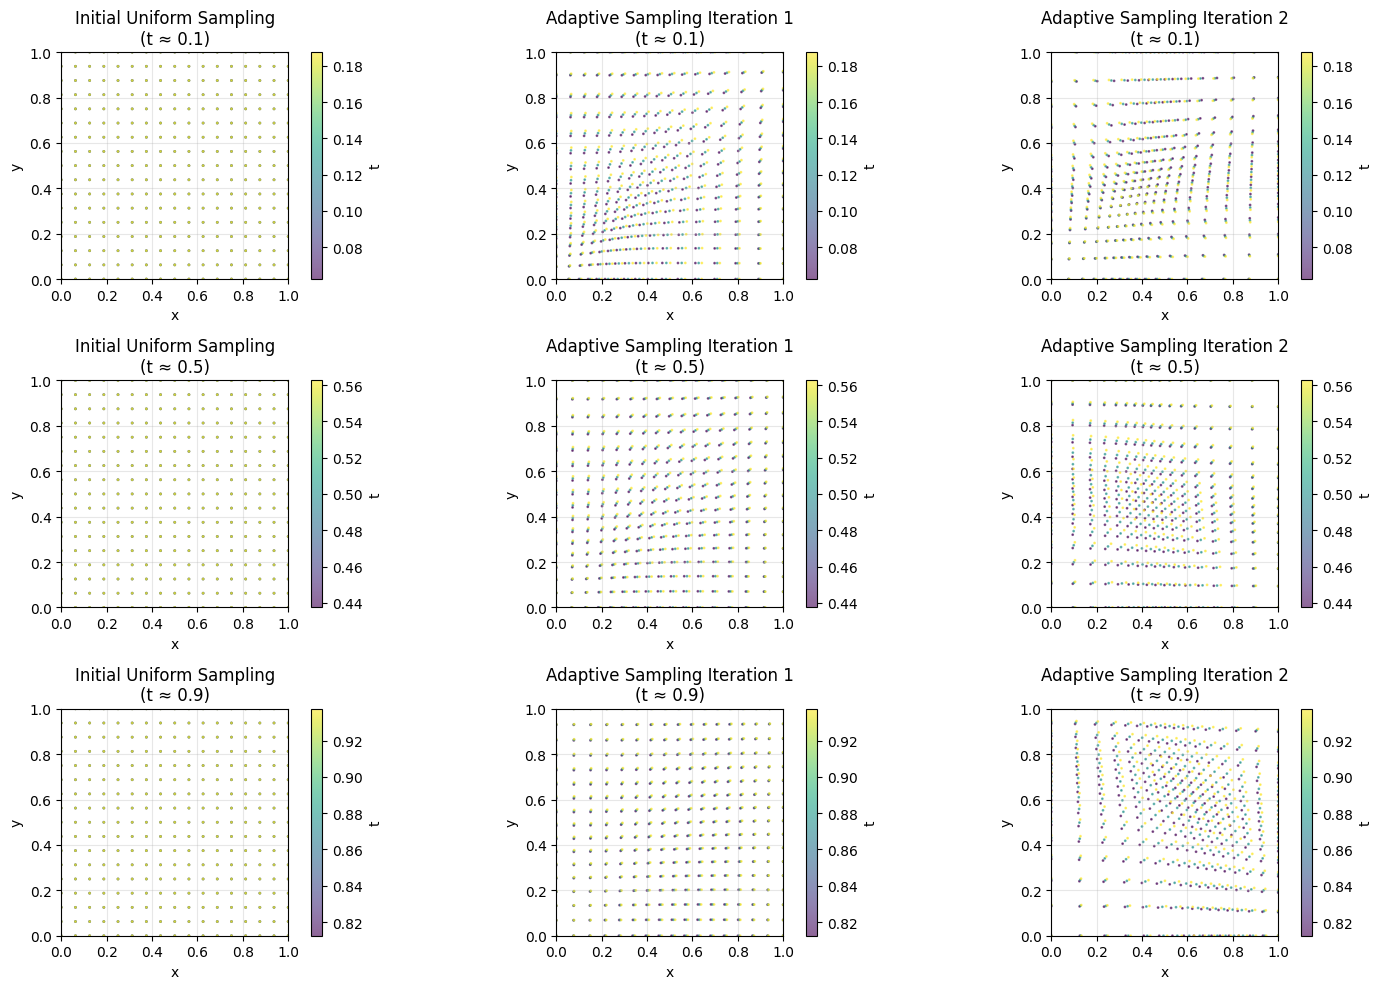


迭代训练完成！
训练完成！


In [98]:
################################################################################
# 执行迭代训练
################################################################################

# 运行迭代训练
trained_model, training_history = iterative_training_with_adaptive_sampling(
    initial_epochs=2000,      # 初始训练轮数
    adaptive_epochs=4000,     # 每次自适应后的训练轮数
    num_iterations=2,         # 迭代次数
    mmpde_training_epochs=100 # MMPDE训练轮数
)

print("训练完成！")

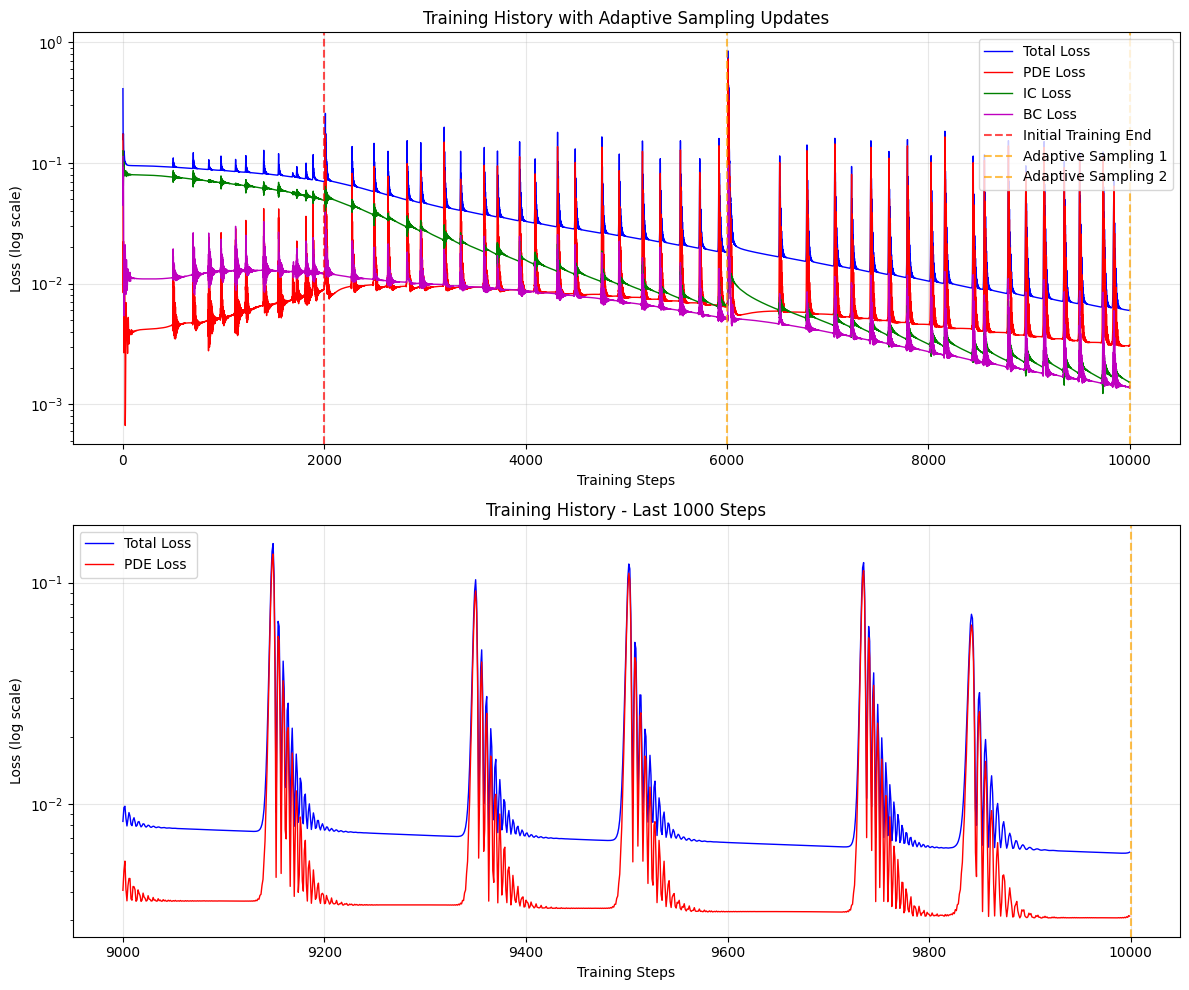

In [99]:
################################################################################
# 可视化训练历史（显示采样更新点）
################################################################################
def plot_training_history_with_sampling(history):
    """绘制带有采样更新标记的训练历史"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # 绘制损失历史
    epochs = range(len(history['loss_history']))
    
    ax1.semilogy(epochs, history['loss_history'], 'b-', linewidth=1, label='Total Loss')
    ax1.semilogy(epochs, history['pde_loss_history'], 'r-', linewidth=1, label='PDE Loss')
    ax1.semilogy(epochs, history['ic_loss_history'], 'g-', linewidth=1, label='IC Loss')
    ax1.semilogy(epochs, history['bc_loss_history'], 'm-', linewidth=1, label='BC Loss')
    
    # 添加采样更新的垂直线
    for i, update_point in enumerate(history['sampling_iterations']):
        color = 'red' if i == 0 else 'orange'
        label = 'Initial Training End' if i == 0 else f'Adaptive Sampling {i}'
        ax1.axvline(x=update_point, color=color, linestyle='--', alpha=0.7, label=label)
    
    ax1.set_xlabel('Training Steps')
    ax1.set_ylabel('Loss (log scale)')
    ax1.set_title('Training History with Adaptive Sampling Updates')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 绘制局部放大图（最后1000步）
    if len(history['loss_history']) > 1000:
        start_idx = len(history['loss_history']) - 1000
        epochs_zoom = range(start_idx, len(history['loss_history']))
        
        ax2.semilogy(epochs_zoom, history['loss_history'][start_idx:], 'b-', linewidth=1, label='Total Loss')
        ax2.semilogy(epochs_zoom, history['pde_loss_history'][start_idx:], 'r-', linewidth=1, label='PDE Loss')
        
        # 添加最后的采样更新线
        for update_point in history['sampling_iterations']:
            if update_point >= start_idx:
                ax2.axvline(x=update_point, color='orange', linestyle='--', alpha=0.7)
        
        ax2.set_xlabel('Training Steps')
        ax2.set_ylabel('Loss (log scale)')
        ax2.set_title('Training History - Last 1000 Steps')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("iterative_training_history.png", dpi=300, bbox_inches='tight')
    plt.show()

# 绘制训练历史
plot_training_history_with_sampling(training_history)

开始生成多时间切片对比图...
正在处理时间切片 t = 0.25
At t=0.25:
  Max |u error|: 4.631563e-02
  Mean |u error|: 1.506316e-02
  L2 |u error|: 1.918606e-02
正在处理时间切片 t = 0.5
At t=0.5:
  Max |u error|: 1.311368e-01
  Mean |u error|: 5.553382e-02
  L2 |u error|: 6.505176e-02
正在处理时间切片 t = 0.9
At t=0.9:
  Max |u error|: 1.156447e-01
  Mean |u error|: 3.325255e-02
  L2 |u error|: 4.615356e-02


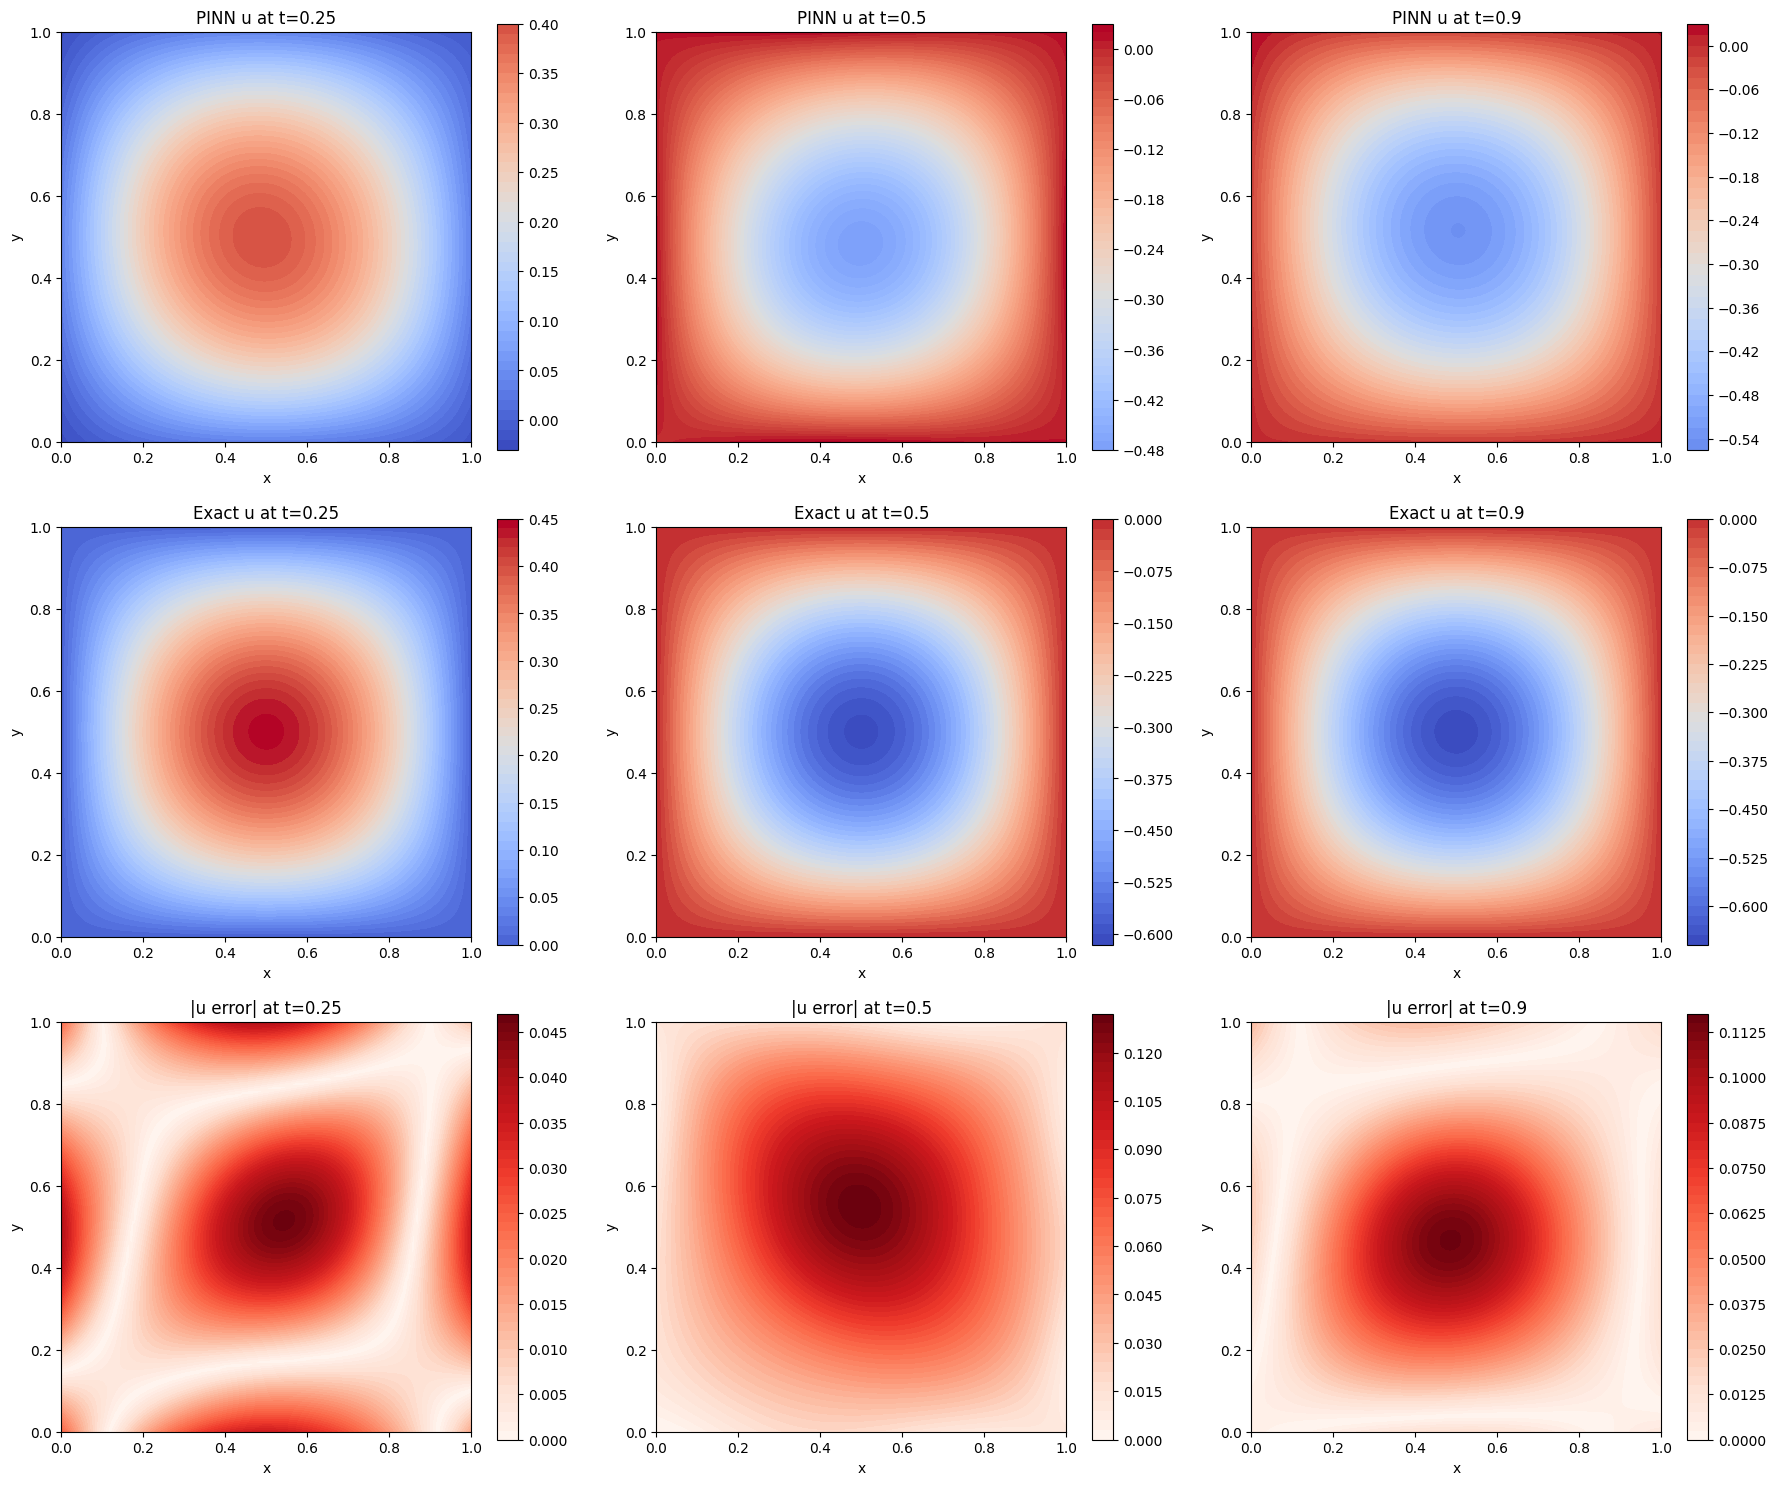


开始分析解的时间演化...
正在计算解的时间演化...
处理 t = 0.00 (1/10)
处理 t = 0.22 (3/10)
处理 t = 0.44 (5/10)
处理 t = 0.67 (7/10)
处理 t = 0.89 (9/10)

时间演化误差统计:
Time     Max Error    Mean Error   L2 Error    
--------------------------------------------------
0.00     1.162717e-01 4.219812e-02 5.356738e-02
0.11     1.069312e-01 3.507099e-02 4.544007e-02
0.22     6.303459e-02 1.897384e-02 2.491336e-02
0.33     3.520895e-02 1.723993e-02 1.907257e-02
0.44     9.940951e-02 4.319581e-02 4.976693e-02
0.56     1.516407e-01 6.398029e-02 7.620912e-02
0.67     1.618243e-01 7.295694e-02 8.779770e-02
0.78     1.498105e-01 6.381036e-02 7.880764e-02
0.89     1.203607e-01 3.611860e-02 4.934873e-02
1.00     5.100684e-02 1.541251e-02 1.886271e-02


In [100]:
################################################################################
# 多时间切片解的可视化对比
################################################################################
def visualize_multiple_time_slices(model, time_values=[0.25, 0.5, 0.9]):
    """
    绘制多个时间切片的解对比图
    """
    n_times = len(time_values)
    
    # 创建网格
    x_grid = np.linspace(0, Lx, 100)
    y_grid = np.linspace(0, Ly, 100)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    # 创建大图：每个时间3行（u预测、u精确、u误差），每个时间1列
    fig, axes = plt.subplots(3, n_times, figsize=(6*n_times, 15))
    
    if n_times == 1:
        axes = axes.reshape(-1, 1)
    
    for time_idx, t_val in enumerate(time_values):
        print(f"正在处理时间切片 t = {t_val}")
        
        # 准备输入张量
        t_tensor = torch.full((X.size, 1), t_val, dtype=torch.float32, device=device)
        x_tensor = torch.tensor(X.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
        y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
        
        # PINN预测
        with torch.no_grad():
            inputs = torch.cat((t_tensor, x_tensor, y_tensor), dim=1)
            uv_pred = model(inputs).cpu().numpy()
            u_pred = uv_pred[:, 0].reshape(X.shape)
        
        # 精确解
        u_exact = exact_solution_u(X, Y, t_val)
        
        # 误差
        error_u = np.abs(u_pred - u_exact)
        
        # 设置颜色范围以便比较
        u_min = min(np.min(u_pred), np.min(u_exact))
        u_max = max(np.max(u_pred), np.max(u_exact))
        
        # PINN预测的u
        im1 = axes[0, time_idx].contourf(X, Y, u_pred, levels=50, cmap='coolwarm', 
                                        vmin=u_min, vmax=u_max)
        axes[0, time_idx].set_title(f'PINN u at t={t_val}')
        axes[0, time_idx].set_xlabel('x')
        axes[0, time_idx].set_ylabel('y')
        axes[0, time_idx].set_aspect('equal')
        plt.colorbar(im1, ax=axes[0, time_idx])
        
        # 精确解的u
        im2 = axes[1, time_idx].contourf(X, Y, u_exact, levels=50, cmap='coolwarm',
                                        vmin=u_min, vmax=u_max)
        axes[1, time_idx].set_title(f'Exact u at t={t_val}')
        axes[1, time_idx].set_xlabel('x')
        axes[1, time_idx].set_ylabel('y')
        axes[1, time_idx].set_aspect('equal')
        plt.colorbar(im2, ax=axes[1, time_idx])
        
        # 误差
        im3 = axes[2, time_idx].contourf(X, Y, error_u, levels=50, cmap='Reds')
        axes[2, time_idx].set_title(f'|u error| at t={t_val}')
        axes[2, time_idx].set_xlabel('x')
        axes[2, time_idx].set_ylabel('y')
        axes[2, time_idx].set_aspect('equal')
        plt.colorbar(im3, ax=axes[2, time_idx])
        
        # 打印误差统计
        print(f"At t={t_val}:")
        print(f"  Max |u error|: {np.max(error_u):.6e}")
        print(f"  Mean |u error|: {np.mean(error_u):.6e}")
        print(f"  L2 |u error|: {np.sqrt(np.mean(error_u**2)):.6e}")
    
    plt.tight_layout()
    # plt.savefig("multiple_time_slices_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

def visualize_solution_evolution_animation_data(model, time_values=None):
    """
    生成解演化的数据用于分析
    """
    if time_values is None:
        time_values = np.linspace(0, T, 10)
    
    # 创建网格
    x_grid = np.linspace(0, Lx, 50)  # 降低分辨率以加快计算
    y_grid = np.linspace(0, Ly, 50)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    # 存储数据
    results = {
        'time_values': time_values,
        'x_grid': X,
        'y_grid': Y,
        'u_pred_series': [],
        'u_exact_series': [],
        'error_series': []
    }
    
    print("正在计算解的时间演化...")
    
    for i, t_val in enumerate(time_values):
        if i % 2 == 0:  # 每两个时间步打印一次进度
            print(f"处理 t = {t_val:.2f} ({i+1}/{len(time_values)})")
        
        # 准备输入张量
        t_tensor = torch.full((X.size, 1), t_val, dtype=torch.float32, device=device)
        x_tensor = torch.tensor(X.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
        y_tensor = torch.tensor(Y.flatten(), dtype=torch.float32, device=device).reshape(-1, 1)
        
        # PINN预测
        with torch.no_grad():
            inputs = torch.cat((t_tensor, x_tensor, y_tensor), dim=1)
            uv_pred = model(inputs).cpu().numpy()
            u_pred = uv_pred[:, 0].reshape(X.shape)
        
        # 精确解
        u_exact = exact_solution_u(X, Y, t_val)
        
        # 误差
        error_u = np.abs(u_pred - u_exact)
        
        results['u_pred_series'].append(u_pred)
        results['u_exact_series'].append(u_exact)
        results['error_series'].append(error_u)
    
    # 计算全局误差统计
    all_errors = np.array(results['error_series'])
    max_errors = [np.max(err) for err in all_errors]
    mean_errors = [np.mean(err) for err in all_errors]
    l2_errors = [np.sqrt(np.mean(err**2)) for err in all_errors]
    
    print("\n时间演化误差统计:")
    print("=" * 50)
    print(f"{'Time':<8} {'Max Error':<12} {'Mean Error':<12} {'L2 Error':<12}")
    print("-" * 50)
    for t, max_err, mean_err, l2_err in zip(time_values, max_errors, mean_errors, l2_errors):
        print(f"{t:<8.2f} {max_err:<12.6e} {mean_err:<12.6e} {l2_err:<12.6e}")
    
    return results

# 可视化多个时间切片
print("开始生成多时间切片对比图...")
visualize_multiple_time_slices(trained_model, time_values=[0.25, 0.5, 0.9])

# 分析解的时间演化
print("\n开始分析解的时间演化...")
evolution_data = visualize_solution_evolution_animation_data(trained_model)